# Dataset & LIbraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import os

import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers, Sequential

import matplotlib.pyplot as plt
import numpy as np
#from sklearn.utils import 
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
source_dir = "/kaggle/input/datasets/geadalfa/cracked-non-cracked-surface-datasets/Bangunan Retak"
dest_dir = "/kaggle/working/NewDataset"

Splitting into separate Train, Val & Test folders

In [ ]:
import splitfolders
splitfolders.ratio(source_dir, output=dest_dir, ratio=(.8, .15, .05), group_prefix=None, move=False)

# Preprocessing

Image Dataset Preprocessing and Loading

In [6]:
batch_size = 64
image_size = (224, 224)

train = keras.preprocessing.image_dataset_from_directory(dest_dir + '/train', label_mode = "categorical", batch_size = batch_size, image_size = image_size, )
val = keras.preprocessing.image_dataset_from_directory(dest_dir + '/val', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )
test = keras.preprocessing.image_dataset_from_directory(dest_dir + '/test', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )

Found 76873 files belonging to 2 classes.


I0000 00:00:1778337008.664521      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778337008.671033      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14413 files belonging to 2 classes.
Found 4806 files belonging to 2 classes.


Performance Optimization: Prefetch

In [7]:
train_copy = train
test_copy = test
train = train.prefetch(buffer_size=tf.data.AUTOTUNE)
val = val.prefetch(buffer_size=tf.data.AUTOTUNE)
test = test.prefetch(buffer_size=tf.data.AUTOTUNE)

Class Weight Computation for Imbalanced Datasets

In [8]:
import os
import numpy as np
from sklearn.utils import class_weight

# 1. Define the path to your training folder 
# (This should match what you used in image_dataset_from_directory)
train_dir = dest_dir + '/train'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(train_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_train_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_train_simulated.extend([i] * num_images)

y_train_simulated = np.array(y_train_simulated)

# 4. Compute the class weights using sklearn
class_labels = np.unique(y_train_simulated)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train_simulated
)

# 5. Format into the dictionary Keras expects
class_weights = dict(zip(class_labels, class_weights_array))

# Display the results
class_indices = {class_names[i]: i for i in range(len(class_names))}
print(f"Class indices: {class_indices}")
print(f"Calculated weights: {class_weights}")

Class indices: {'Cracked': 0, 'Non Cracked': 1}
Calculated weights: {np.int64(0): np.float64(1.6867731601351648), np.int64(1): np.float64(0.7106552527456274)}


# Hyperparameter optimization

In [9]:
!pip install optuna
!pip install optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 4.9 MB/s eta 0:00:00


Transfer Learning Optimization with DenseNet121 and Optuna Hyperparameter Tuning

In [ ]:
import optuna
from optuna.integration import TFKerasPruningCallback
import tensorflow as tf
from tensorflow.keras import layers, regularizers

# Take 200 batches for training and 50 batches for validation.
tune_train = train.take(200)

def objective(trial):
    tf.keras.backend.clear_session()
    
    # 1. Suggest Hyperparameters for the Head and Optimizer
    dense_units = trial.suggest_int("dense_units", 128, 512, step=128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    
    # 2. Optuna can even tune how many layers of the base model to unfreeze!
    # For DenseNet121, freezing everything usually works well for the first pass, 
    # but let's allow Optuna to optionally unfreeze the top layers.
    unfreeze_layers = trial.suggest_categorical("unfreeze_layers", [0, 10, 20])
    
    # 3. Load Pre-trained DenseNet121 (Exclude the original ImageNet 1000-class head)
    base_model = tf.keras.applications.DenseNet121(
        weights='imagenet', 
        include_top=False, 
        input_shape=(224, 224, 3)
    )
    
    # Freeze the base model layers based on Optuna's suggestion
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_layers] if unfreeze_layers > 0 else base_model.layers:
        layer.trainable = False

    # 4. Build Final Model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(224, 224, 3)))
   
    model.add(base_model)
    model.add(layers.GlobalAveragePooling2D())

    # Custom Classification Head tuned by Optuna
    model.add(layers.Dense(dense_units, use_bias=False, kernel_regularizer=regularizers.l2(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(2, activation="softmax"))

    # 5. Compile Model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 6. Callbacks & Training
    callbacks = [
        TFKerasPruningCallback(trial, monitor="val_accuracy"),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
    ]
    
    history = model.fit(
        tune_train, # Your 200-batch subset
        validation_data=val,
        epochs=10,  # Pre-trained models converge faster, 10 is plenty for tuning
        callbacks=callbacks,
        class_weight=class_weights,
    )
    
    return max(history.history["val_accuracy"])

# Run the study
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=25) 

print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

[I 2026-05-09 14:34:00,311] A new study created in memory with name: no-name-ed4ebbfb-0eb4-4bbf-8e8f-5dd3b2b5df3a


Epoch 1/10


I0000 00:00:1778337257.141804     129 service.cc:152] XLA service 0x7f1d10224940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778337257.141848     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778337257.141853     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778337261.386138     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778337280.459134     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 118s 401ms/step - accuracy: 0.8079 - loss: 0.4748 - val_accuracy: 0.8664 - val_loss: 0.3194
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.8758 - loss: 0.3321 - val_accuracy: 0.8745 - val_loss: 0.3174
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 58s 293ms/step - accuracy: 0.8877 - loss: 0.2975 - val_accuracy: 0.8671 - val_loss: 0.3394
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 58s 293ms/step - accuracy: 0.8904 - loss: 0.2830 - val_accuracy: 0.8997 - val_loss: 0.2397
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.8992 - loss: 0.2586 - val_accuracy: 0.9016 - val_loss: 0.2420
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.9051 - loss: 0.2438 - val_accuracy: 0.8957 - val_loss: 0.2606
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 58s 292ms/step - accuracy: 0.9130 - loss: 0.2323 - val_accuracy: 0.8246 - val_loss: 0.5405
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.9165 - loss: 0.2241 - va

[I 2026-05-09 14:44:47,193] Trial 0 finished with value: 0.9089710712432861 and parameters: {'dense_units': 384, 'dropout_rate': 0.38426610774637904, 'lr': 0.00016123421225825726, 'unfreeze_layers': 20}. Best is trial 0 with value: 0.9089710712432861.


...

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 106s 395ms/step - accuracy: 0.7849 - loss: 0.4872 - val_accuracy: 0.8787 - val_loss: 0.3093
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 296ms/step - accuracy: 0.8779 - loss: 0.3158 - val_accuracy: 0.9133 - val_loss: 0.2418
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.8927 - loss: 0.2859 - val_accuracy: 0.8957 - val_loss: 0.2638
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.8968 - loss: 0.2695 - val_accuracy: 0.9051 - val_loss: 0.2381
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 296ms/step - accuracy: 0.9030 - loss: 0.2561 - val_accuracy: 0.9195 - val_loss: 0.2243
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 295ms/step - accuracy: 0.9083 - loss: 0.2430 - val_accuracy: 0.9111 - val_loss: 0.2358
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 295ms/step - accuracy: 0.9130 - loss: 0.2308 - val_accuracy: 0.9145 - val_loss: 0.2249
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 295ms/step - accuracy: 0.9177 - loss: 

[I 2026-05-09 16:44:18,284] Trial 23 finished with value: 0.9195170998573303 and parameters: {'dense_units': 128, 'dropout_rate': 0.34354638051945274, 'lr': 0.00013662430640754862, 'unfreeze_layers': 20}. Best is trial 1 with value: 0.9248595237731934.


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8094 - loss: 0.4769

[I 2026-05-09 16:46:08,219] Trial 24 pruned. Trial was pruned at epoch 0.


Best trial: 0.9248595237731934
Best params: {'dense_units': 384, 'dropout_rate': 0.4228080027623846, 'lr': 0.00029786720003929296, 'unfreeze_layers': 20}


In [17]:
print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

Best trial: 0.9248595237731934
Best params: {'dense_units': 384, 'dropout_rate': 0.4228080027623846, 'lr': 0.00029786720003929296, 'unfreeze_layers': 20}


# Training

Reconstructing and Training the Final Model with Optimal Hyperparameters

In [ ]:
# --- 1. Parse the Best Parameters Automatically ---
best_params = study.best_params

print("Training final Transfer Learning model with parameters:", best_params)

# Load Pre-trained DenseNet121 Base
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# Apply the best unfreezing strategy found by Optuna
base_model.trainable = True
unfreeze_layers = best_params['unfreeze_layers']

if unfreeze_layers == 0:
    base_model.trainable = False  # Freeze entirely
else:
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False   # Freeze all but the top N layers


# --- 2. Re-instantiate Data Augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

# --- 3. Build Final Model Dynamically using Parsed Variables ---
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model.add(data_augmentation)

model.add(base_model)
model.add(layers.GlobalAveragePooling2D())

# Classification Head using parsed 'dense_units' and 'dropout_rate'
model.add(layers.Dense(best_params['dense_units'], use_bias=False, kernel_regularizer=regularizers.l2(1e-5)))
model.add(layers.BatchNormalization())
model.add(layers.ReLU())
model.add(layers.Dropout(best_params['dropout_rate']))
model.add(layers.Dense(2, activation="softmax"))

# --- 4. Compile using the parsed 'lr' ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Final Callbacks ---
callbacks = [
    # Save with a new name so you don't overwrite your custom CNN
    tf.keras.callbacks.ModelCheckpoint("best_crack_model_densenet.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1, mode="min")
]

# --- 6. Train on the FULL Dataset ---
# Notice we are using 'train' and 'val' here, NOT 'tune_train'
history = model.fit(
    train,               
    validation_data=val,
    epochs=50, # Pre-trained models usually converge much faster than 100 epochs
    callbacks=callbacks,
    class_weight=class_weights
)

Training final Transfer Learning model with parameters: {'dense_units': 384, 'dropout_rate': 0.4228080027623846, 'lr': 0.00029786720003929296, 'unfreeze_layers': 20}
Epoch 1/50
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 416s 329ms/step - accuracy: 0.9123 - loss: 0.2610 - val_accuracy: 0.9506 - val_loss: 0.1594 - learning_rate: 2.9787e-04
Epoch 2/50
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 387s 322ms/step - accuracy: 0.9392 - loss: 0.1930 - val_accuracy: 0.9468 - val_loss: 0.1553 - learning_rate: 2.9787e-04
Epoch 3/50
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 387s 322ms/step - accuracy: 0.9443 - loss: 0.1815 - val_accuracy: 0.9480 - val_loss: 0.1563 - learning_rate: 2.9787e-04
Epoch 4/50
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9489 - loss: 0.1744
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001489335991209373.
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 387s 322ms/step - accuracy: 0.9489 - loss: 0.1743 - val_accuracy: 0.9432 - val_loss: 0.1680 - learning_rate: 2.9787e-04
Epoch 5/50
1202/1202 ━━━━━━━━━━

# Evaluation & Visualization

Model Performance Evaluation on Test Dataset

In [19]:
#loss, accuracy, precision, recall
print(model.evaluate(test))

76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 264ms/step - accuracy: 0.9564 - loss: 0.1126
[0.1278076022863388, 0.9625468254089355]


Visualizing Training History: Loss and Accuracy Curves

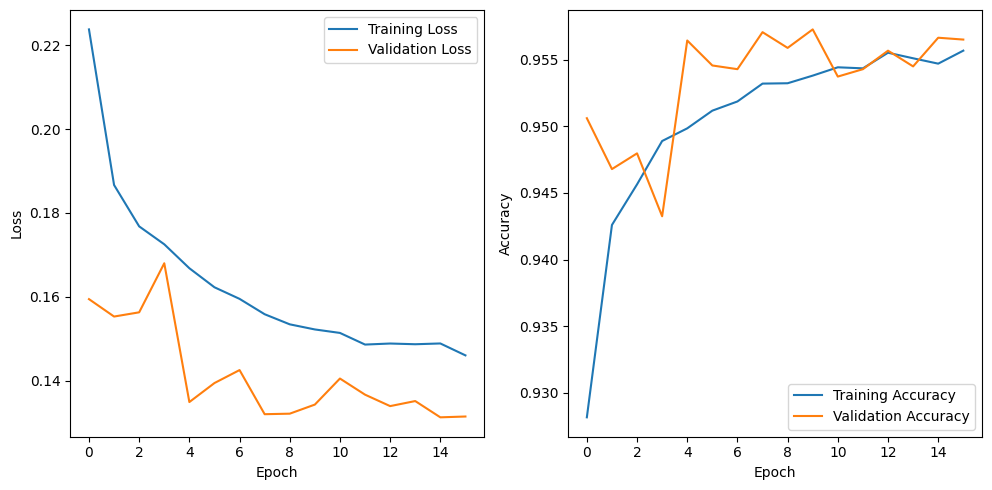

In [20]:
plt.figure(figsize=(15, 5))

# --- Loss ---
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- Accuracy ---
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Confusion Matrix Visualization and Error Analysis

In [21]:
test_dir = dest_dir + '/test'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(test_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_test_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_test_simulated.extend([i] * num_images)

y_true = np.array(y_test_simulated)



# Use the model to predict the classes
y_pred = np.argmax(model.predict(test), axis=1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step


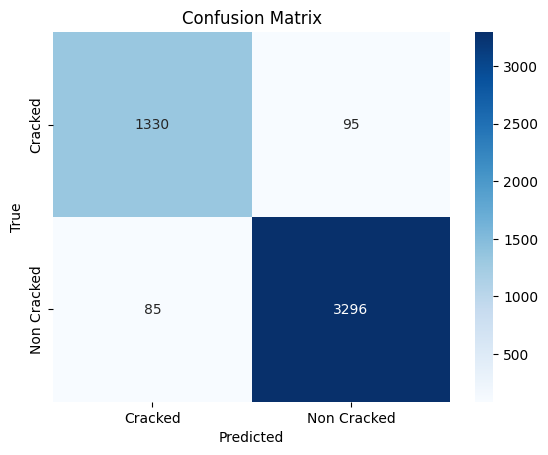

[[1330   95]
 [  85 3296]]


In [22]:
import seaborn as sns

# Compute and print confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualize confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_copy.class_names, yticklabels=test_copy.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print(conf_matrix)

Reconstructing DenseNet121 Architecture and Loading Pre-trained Weights

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

# 1. Define the exact same architecture as used in Cell 13/18
best_params = {'dense_units': 384, 'dropout_rate': 0.4228080027623846, 'lr': 0.00029786720003929296, 'unfreeze_layers': 20}

# Define Data Augmentation (must match training exactly)
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

# Define Base Model
base_model = tf.keras.applications.DenseNet121(
    weights=None, # Set to None since we are loading our own weights
    include_top=False, 
    input_shape=(224, 224, 3)
)

# Build the Sequential wrapper
Model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(best_params['dense_units'], use_bias=False, kernel_regularizer=regularizers.l2(1e-5)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(best_params['dropout_rate']),
    layers.Dense(2, activation="softmax")
])

# 2. Load the weights from the .keras file
# Keras 3 allows load_weights to read from a full model file
Model.load_weights("best_crack_model_densenet.keras")

# 3. Compile (required if you want to evaluate or continue training)
Model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model loaded successfully!")
Model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       393,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,433,026 (28.35 MB)

 Trainable params: 7,348,610 (28.03 MB)

 Non-trainable params: 84,416 (329.75 KB)